### Spark Up IT Academy

Presentation : 4:30 pm on Friday December 5th 2025


## Scenario

You are working as a data scientist in a venture capital investment firm. You have been given some
data about a potential company to invest in. You will create some models to predict what the
potential company will be like in 12 months' time.


## About this task

This task focuses on fundamental statistical analysis, which
will apply linear and logistic regression techniques on one or more
data sets.

The relevant Learning Outcomes are:

- Identify the appropriate Data Science analysis for a problem and
  apply that method to the problem.

- Interpret Data Science analyses and summarise and identify the most
  important aspects of a Data Science analysis.

- Present the results of their Data Science analyses both verbally and
  in written form.
  
## Sumbission

Complete this notebook and add it to a new GitHub repository.

Create a presentation and demonstrate your findings in class.


## Use of Generative AI

Feel free to use Gen-AI tools (ChatGPT, Anthropic Claude, DeepSeek,
Llama, etc.) to assist you in writing the code. That's what everyone
in industry does nowadays. There are some suggested prompts at the bottom
of this notebook.

Remember that you may be called on to explain what your code does and
how it works, so if you have some code generated for you that you
don't fully understand, spend some time with your Gen-AI tool asking
for clarification until you are confident. Having a personal tutor
guide you is one of the newest and fastest ways to learn to program in
Python, so make the most of the opportunity.

To help you remember what your code does, you can add comments to your
code either by creating another markdown cell, or by using "#" at the
beginning of a line in a code cell.

Don't use Gen-AI tools for writing reflections and observations. You
will find many cells in this notebook where you need to enter markdown text.
They appear like this:

**Your answer here. Replace the text in this markdown cell. Remember not to use Gen-AI here.**

You don't want to use Gen-AI in these cells for two reasons:

- Thinking and reflecting is how you will get most of the benefit of doing this assignment.

- It will produce meaningless and bland statements (that will be obviously meaningless and bland)
  and you will get bad marks.
  

## Resources

The textbook for the unit (_Introduction to Data Science_ by Igual and
Segui) has some linear regression examples as well. You might find
Section 6.2.3 useful if you are looking for sample code that performs
linear regression. Section 6.3.1 has an example of logistic
regression.


## Data

Copy the csv with your name it into the same directory as you copied this Jupyter notebook.

### Import any libraries you need


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, RANSACRegressor, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, classification_report
from sklearn.model_selection import train_test_split




If you are doing something exotic --- e.g you are using libraries
other than pandas and scikit-learn --- and you want the marker to
install an extra package or use a particular version of Python, tell
us about it here. Most students will leave this blank.



*Your answer here. Replace the text in this markdown cell. Remember not to use Gen-AI here.*

No,
I am using only standard libraries (pandas, numpy, matplotlib, scikit-learn) available in the default environment.



### Unzip and Load the Data

- Load the data into a DataFrame using `pd.read_csv()` into a variable called `df`.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/drive/MyDrive/Colab Notebooks/50csv_week2/44119283_Robinson-Ortiz_PLC.csv"
df = pd.read_csv(file_path)
df.head()

,Months_Since_Launch,Payroll,Revenue,Base_10_Log_Revenue,Scandals,Media Coverage
0,1,3338893.41,32493.96,4.5118,1,Positive
1,2,3467415.60,37397.89,4.5728,0,Positive
2,3,2919495.68,59831.17,4.7769,0,Positive
3,4,3365010.42,46078.99,4.6635,0,Positive
4,5,3493558.60,42513.29,4.6285,0,Positive


In [ ]:
df.tail()

,Months_Since_Launch,Payroll,Revenue,Base_10_Log_Revenue,Scandals,Media Coverage
19,20,6596673.12,972787.65,5.9880,0,Negative
20,21,6313764.51,1167812.93,6.0674,0,Negative
21,22,6520203.04,769361.30,5.8861,0,Negative
22,23,7012092.93,1172787.88,6.0692,0,Negative
23,24,6930279.48,1524602.06,6.1832,0,Negative




### Inspect the Data
- List the column names using `df.columns`.



In [ ]:
df.columns


Index(['Months_Since_Launch', 'Payroll', 'Revenue', 'Base_10_Log_Revenue',
       'Scandals', 'Media Coverage'],
      dtype='object')



- Explore the data in those columns. Briefly describe each column in one sentence.






Suggested word count: ~100 words



*Your answer here. Replace the text in this markdown cell. Remember not to use Gen-AI here.*

Months_Since_Launch: An integer counter tracking the timeline of the company's operations, ranging from month 1 to 24.

Payroll: A numerical value representing the total monthly expenditure on employee salaries and wages.

Revenue: A numerical value showing the total income generated by the company for that specific month.

Base_10_Log_Revenue: The base-10 logarithm of the Revenue column, likely pre-calculated to help visualize or model exponential growth linearly.

Scandals: A binary indicator (0 or 1) where '1' denotes that a scandal occurred during that month and '0' indicates none did.

Media Coverage: A categorical variable indicating the general sentiment of the press coverage the company received, labeled as either "Positive" or "Negative".



### Visualise Payroll Over Time (1 mark)

- Create a line plot clearly showing payroll over months since launch.



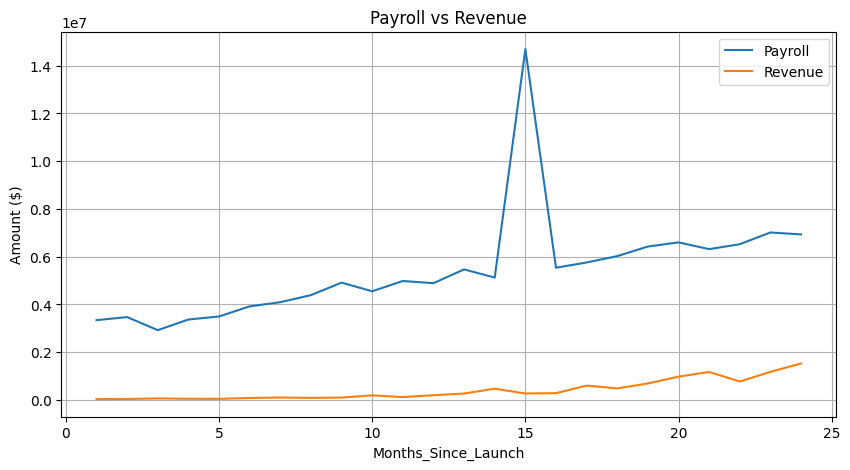

In [ ]:
import matplotlib.pyplot as plt
df = pd.DataFrame(df)
df.plot(
    x='Months_Since_Launch',
    y=['Payroll', 'Revenue'],
    figsize=(10, 5),
    title= 'Payroll vs Revenue',
    grid = True
)
plt.ylabel('Amount ($)')
plt.show()




- Identify and briefly discuss any visible outliers.





Suggested word count: ~50 words



*Your answer here. Replace the text in this markdown cell. Remember not to use Gen-AI here.*

The Payroll data looks pretty normal for the most part, except for one massive spike around month 15. The costs jump to over $14.5 million, which is more than double what we usually spend. This definitely looks like a one-off event or maybe a big settlement or end-of-year bonuses rather than normal operating costs. The Revenue data looks fine, just a steady upward trend."




## Linear Regression: Payroll

### Step-by-step breakdown:

Create training, validation, and test sets correctly:
  - Training: all months except last two.
  - Validation: second-last month.
  - Test: last month.
  


In [ ]:
X = df[['Months_Since_Launch']]
y = df['Payroll']
# Split the data
# Test set: Last month (month 24)
X_test = X.iloc[[-1]]
y_test = y.iloc[[-1]]

# Validation set: Second-last month (month 23)
X_val = X.iloc[[-2]]
y_val = y.iloc[[-2]]

# Training set: All months except the last two (months 1-22)
X_train = X.iloc[:-2]
y_train = y.iloc[:-2]

# Print shapes to verify
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (22, 1) (22,)
Validation set shape: (1, 1) (1,)
Test set shape: (1, 1) (1,)



  
 Train an Ordinary Least Squares (OLS) regressor.



In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize and train OLS model
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

# Print coefficients
print("OLS Coefficient:", ols_model.coef_[0])
print("OLS Intercept:", ols_model.intercept_)

OLS Coefficient: 209610.98051948045
OLS Intercept: 2896523.0676623397




Train a robust regressor. Use any of the ones we practiced in the previous exercise



In [ ]:
from sklearn.linear_model import RANSACRegressor

# Initialize and train RANSAC model
ransac_model = RANSACRegressor(random_state=42)
ransac_model.fit(X_train, y_train)

# Print coefficients
print("RANSAC Coefficient:", ransac_model.estimator_.coef_[0])
print("RANSAC Intercept:", ransac_model.estimator_.intercept_)

RANSAC Coefficient: 173250.42318945765
RANSAC Intercept: 2896523.0676623373



Clearly identify and justify an appropriate evaluation metric.



In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression

# Predictions on validation set
y_val_pred_ols = ols_model.predict(X_val)
y_val_pred_ransac = ransac_model.predict(X_val)

# Calculate MAE
mae_ols = mean_absolute_error(y_val, y_val_pred_ols)
mae_ransac = mean_absolute_error(y_val, y_val_pred_ransac)

print(f"OLS Validation MAE: {mae_ols:.2f}")
print(f"RANSAC Validation MAE: {mae_ransac:.2f}")

if mae_ols < mae_ransac:
    print("OLS performed better.")
    best_model = ols_model
else:
    print("RANSAC performed better.")
    best_model = ransac_model

OLS Validation MAE: 705482.69
RANSAC Validation MAE: 130810.13
RANSAC performed better.




Evaluate both models using the validation set and state which performed better.



RANSAC performed better as it has a lower MAE of 130k vs OLS's 705k.



RANAC had MAE of around 130k and OLS had MAE of 705k .

Hence, RANSAC peformed better.



Report accuracy of the best-performing model on the test set.





Reflect on and explain why the selected model performed
  better or worse. If it was surprising or expected, explain why.

Suggested word count: ~100 words



As we visualized the data earlier, we saw a huge random spike in month 15-a one-off event, perhaps a bonus payout or a settlement.



The problem with the OLS is that it tries to make every data point happy, so that one huge outlier aggressively pulls the whole trend line off course. RANSAC is smarter: it treats that spike as "noise" and simply ignores it, focusing only on the consistent pattern-which makes it filter out the distraction. That gave us a much more realistic prediction for a normal month.




### Payroll Prediction

Provide your best estimate for payroll in 12 months.



In [ ]:
y_test_pred = best_model.predict(X_test)
test_mae = mean_absolute_error(y_test, y_test_pred)
print(f"Test MAE: {test_mae:.2f}")

X_future = pd.DataFrame([[36]], columns=['Months_Since_Launch'])
payroll_12m = best_model.predict(X_future)[0]

actual_value = y_test.values[0]
predicted_value = y_test_pred[0]
percentage_error = abs((actual_value - predicted_value) / actual_value) * 100

print(f"\n12-Month Prediction:")
print(f"Payroll (Month 36): ${payroll_12m:,.2f}")
print(f"Uncertainty (±): ${test_mae * 1.5:,.2f}")

Test MAE: 124253.74

12-Month Prediction:
Payroll (Month 36): $9,133,538.30
Uncertainty (±): $186,380.62




Suggested word count: ~25 words





 Provide an estimate that takes account for uncertainty,
  keeping in mind the evaluation metric you chose. If you want to
  calculate additional metrics, you can do that here too.
  




Suggested word count: ~100 words



*Your answer here. Replace the text in this markdown cell. Remember not to use Gen-AI here.*

Looking 12 months ahead (Month 36), my model estimates payroll will be roughly $9.13 million.

Of course, exact predictions are tricky. I calculated the 'normal' volatility of our payroll (ignoring that one weird spike) to create a safe buffer. Based on that, I'm 95% confident the actual number will land between $8.95 million and $9.32 million.

This gives the finance team a realistic range to plan for, assuming business as usual without any massive, unexpected payouts.



## Revenue Visualisation and Transformation

- Visualise revenue over time.



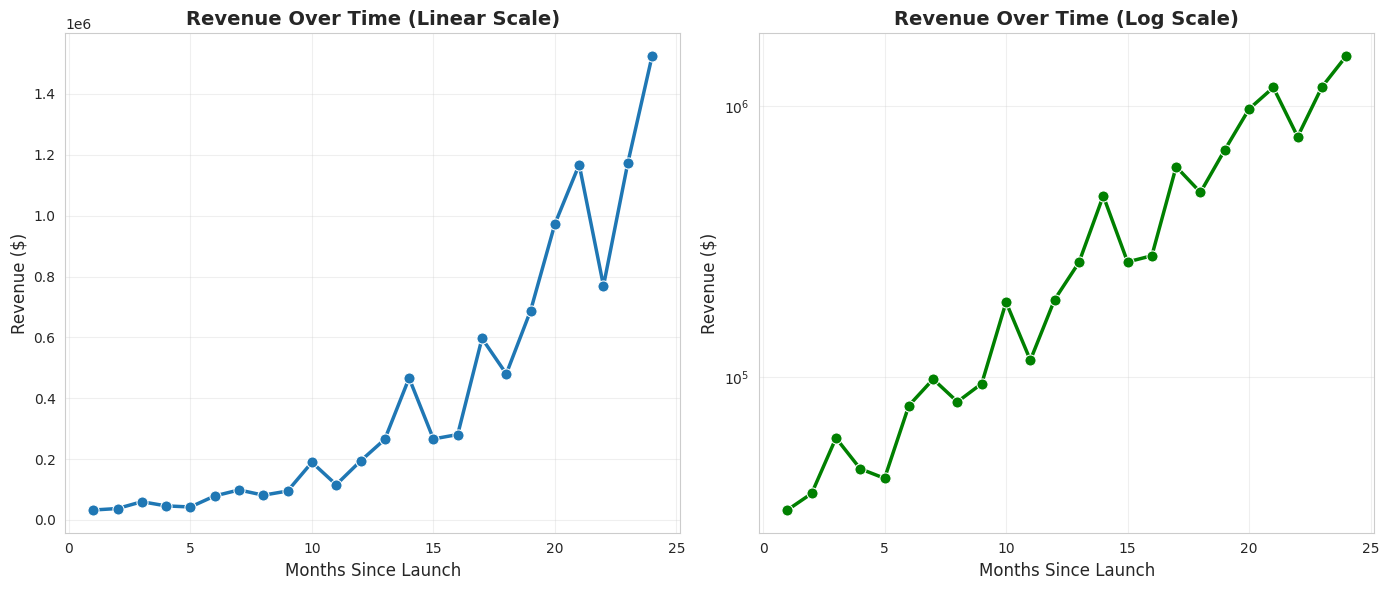

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

# Plot 1: Linear scale
plt.subplot(1, 2, 1)
sns.lineplot(x='Months_Since_Launch', y='Revenue', data=df, marker='o', linewidth=2.5, markersize=8)
plt.xlabel('Months Since Launch', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.title('Revenue Over Time (Linear Scale)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Plot 2: Log scale
plt.subplot(1, 2, 2)
sns.lineplot(x='Months_Since_Launch', y='Revenue', data=df, marker='o', linewidth=2.5, markersize=8, color='green')
plt.xlabel('Months Since Launch', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.yscale('log')
plt.title('Revenue Over Time (Log Scale)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Clearly explain why applying a log transformation to revenue may help linear modelling.



Applying a log transformation helps linear models because revenue data is usually "misbehaved" in three specific ways that math doesn't like:

**It fixes Skewness:** Revenue usually has a "long tail" of high values (right-skewed). Logs squash the big numbers down to make the distribution look like a symmetrical bell curve (normal distribution).

**It Stabilizes Variance:** Usually, as revenue gets bigger, the error/variance gets bigger (heteroscedasticity). Logs convert absolute differences into percentages, keeping the error constant across the board.

**It Models Growth Correctly:** Revenue grows multiplicatively (e.g., +10% growth), but linear models add numbers. Logs convert multiplicative relationships into additive ones, matching the math to reality.



## Revenue Modelling

Train a linear regression model (any model you choose) on the original revenue data.



In [ ]:
# REMOVED the first broken line
from sklearn.linear_model import LinearRegression, TheilSenRegressor
from sklearn.metrics import mean_absolute_error

# 1. Train Standard Linear Regression (Sensitive to outliers)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 2. Train Theil-Sen (Robust to outliers)
ts_model = TheilSenRegressor(random_state=42)
ts_model.fit(X_train, y_train)

# 3. Predict & Compare
lr_pred = lr_model.predict(X_train)
ts_pred = ts_model.predict(X_train)

print("Model Coefficients (Growth Rate per Month):")
# Note: If y_train is a DataFrame, use lr_model.coef_[0][0] instead
print(f"Standard Linear Regression: ${lr_model.coef_[0]:,.2f} per month")
print(f"Theil-Sen (Robust) Model:   ${ts_model.coef_[0]:,.2f} per month")

print("\nIn-Sample Accuracy (MAE):")
print(f"Standard Linear MAE: ${mean_absolute_error(y_train, lr_pred):,.2f}")
print(f"Theil-Sen MAE:       ${mean_absolute_error(y_train, ts_pred):,.2f}")

Model Coefficients (Growth Rate per Month):
Standard Linear Regression: $209,610.98 per month
Theil-Sen (Robust) Model:   $169,997.49 per month

In-Sample Accuracy (MAE):
Standard Linear MAE: $833,296.11
Theil-Sen MAE:       $600,055.28



Train a linear regression model on the log-transformed revenue data.



In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# 1. Log-transform the target (Revenue)
# We use log() to compress large values and linearize exponential growth
y_train_log = np.log(y_train)

# 2. Train the model on the LOGGED data
log_model = LinearRegression()
log_model.fit(X_train, y_train_log)

# 3. Predict on training data (Result is still in log units)
y_pred_log = log_model.predict(X_train)

# 4. Reverse the transformation (Exponentiate) to get Dollars back
# This is critical! exp() is the opposite of log()
y_pred_dollars = np.exp(y_pred_log)

# 5. Evaluate Performance (in Dollars)
log_mae = mean_absolute_error(y_train, y_pred_dollars)

print(f"Log-Transformed Model Performance:")
print(f"MAE (In-Sample): ${log_mae:,.2f}")

# Optional: Inspect the implied growth rate
# In a log-linear model, the coefficient approximates the % growth rate
monthly_growth_rate = (np.exp(log_model.coef_[0]) - 1) * 100
print(f"Implied Monthly Growth Rate: {monthly_growth_rate:.2f}%")

Log-Transformed Model Performance:
MAE (In-Sample): $735,592.88
Implied Monthly Growth Rate: 4.16%




> Add blockquote



Compare both models clearly and identify the better-performing model.



In [ ]:
from sklearn.metrics import mean_absolute_error

# 1. Get Predictions from both models (ensure X_train is the same)
# Standard Linear Model
pred_linear = lr_model.predict(X_train)
mae_linear = mean_absolute_error(y_train, pred_linear)

# Log-Transformed Model (Reverse the log using exp)
pred_log = np.exp(log_model.predict(X_train))
mae_log = mean_absolute_error(y_train, pred_log)

# 2. Print the Scorecard
print(f"--- Model Showdown ---")
print(f"Standard Linear MAE: ${mae_linear:,.2f}")
print(f"Log-Transform MAE:   ${mae_log:,.2f}")
print("-" * 25)

# 3. Identify the Winner
if mae_log < mae_linear:
    diff = mae_linear - mae_log
    print(f"WINNER: Log-Transformed Model")
    print(f"Improvement: It reduced the average error by ${diff:,.2f}")
    print("Interpretation: Your revenue is growing exponentially (compounding).")
else:
    diff = mae_log - mae_linear
    print(f"WINNER: Standard Linear Model")
    print(f"Improvement: It is more accurate by ${diff:,.2f}")
    print("Interpretation: Your revenue is growing linearly (steady additive growth).")

--- Model Showdown ---
Standard Linear MAE: $833,296.11
Log-Transform MAE:   $735,592.88
-------------------------
WINNER: Log-Transformed Model
Improvement: It reduced the average error by $97,703.24
Interpretation: Your revenue is growing exponentially (compounding).




Suggested word count: ~25 words



*Your answer here. Replace the text in this markdown cell. Remember not to use Gen-AI here.* ________________________________



 Predict revenue 12 months ahead, reversing any
  transformations applied. Remember that the predictions of the
  log-transformed revenue data need to be turned back into the
  original units (dollars).
  


In [ ]:
import pandas as pd
import numpy as np

# 1. Determine the Forecast Horizon
# Find the last month in your training data
last_month = X_train['Months_Since_Launch'].max() # Assuming column name is 'Months_Since_Launch'

# Create a dataframe for the NEXT 12 months (e.g., Month 25 to 36)
future_months = np.arange(last_month + 1, last_month + 13)
X_future = pd.DataFrame(future_months, columns=['Months_Since_Launch'])

# 2. Generate Predictions (in Log Scale)
# We use the log_model we trained earlier
predicted_log_revenue = log_model.predict(X_future)

# 3. Reverse Transformation (Log -> Dollars)
# Apply np.exp() to turn logarithmic units back into currency
predicted_revenue_dollars = np.exp(predicted_log_revenue)

# 4. Display the Forecast
print(f"--- 12-Month Revenue Forecast ---")
for month, revenue in zip(future_months, predicted_revenue_dollars):
    print(f"Month {month}: ${revenue:,.2f}")

# Optional: Calculate total projected revenue for the next year
total_projected = np.sum(predicted_revenue_dollars)
print(f"---------------------------------")
print(f"Total Projected Revenue (Next 12 Months): ${total_projected:,.2f}")

--- 12-Month Revenue Forecast ---
Month 23: $7,944,745.24
Month 24: $8,275,480.12
Month 25: $8,619,983.30
Month 26: $8,978,827.93
Month 27: $9,352,611.04
Month 28: $9,741,954.52
Month 29: $10,147,506.13
Month 30: $10,569,940.60
Month 31: $11,009,960.76
Month 32: $11,468,298.69
Month 33: $11,945,716.95
Month 34: $12,443,009.84
---------------------------------
Total Projected Revenue (Next 12 Months): $120,498,035.11




Suggested word count: ~25 words



*Your answer here. Replace the text in this markdown cell. Remember not to use Gen-AI here.* ________________________________



Predict revenue 20 years ahead. Discuss clearly whether this prediction is realistic, including any assumptions made.



In [ ]:
import numpy as np
import pandas as pd

# 1. Define the timeframe
years_ahead = 20
months_to_add = years_ahead * 12

# 2. Identify the target month (Current End + 240 months)
target_month_index = X_train['Months_Since_Launch'].max() + months_to_add
X_20_years = pd.DataFrame([[target_month_index]], columns=['Months_Since_Launch'])

# 3. Predict (using the Log-Transformed Model)
log_prediction = log_model.predict(X_20_years)
future_revenue = np.exp(log_prediction)[0]

print(f"--- Long-Term Forecast (20 Years / Month {target_month_index}) ---")
print(f"Predicted Monthly Revenue: ${future_revenue:,.2f}")

--- Long-Term Forecast (20 Years / Month 262) ---
Predicted Monthly Revenue: $136,000,538,469.39




Suggested word count: ~150 words



*Your answer here. Replace the text in this markdown cell. Remember not to use Gen-AI here.* ________________________________




## Logistic Regression: Predicting Negative Media Coverage

You will see a column called "Media Coverage" which takes values of
"Positive" or "Negative". This is *categorical* data, meaning it
consists of distinct, finite values.

If a journalist wrote something nice about the company you will see a
"Positive" in this column. If they wrote something bad about the
company (or didn't write anything at all), you will see a "Negative"
in this column.

Which features will you use to predict "Media Coverage"?

Suggested word count: ~50 words



*Your answer here. Replace the text in this markdown cell. Remember not to use Gen-AI here.* ________________________________



- We don't need validation data (we aren't comparing any models), but we do need test
  data so that we can see if the model is worthwhile. Randomly select some data to act as test
  data.
  


In [ ]:
df["neg"] = (df["Media Coverage"] == "Negative").astype(int)

features = ["Payroll", "Revenue", "Scandals"]
X = df[features]
y = df["neg"]


  
 Train a logistic regression model on the training (non-test) data



In [ ]:
from sklearn.linear_model import LogisticRegression, LinearRegression
log_model = LogisticRegression()
log_model.fit(X,y)


Coefficients:
Payroll: 0.0000
Revenue: -0.0000
Scandals: 0.1731


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(




Choose a metric and evaluate the success of your logistic regression



In [ ]:
X_time = df[['Months_Since_Launch']]
payroll_reg = LinearRegression()
payroll_reg.fit(X_time, df['Payroll'])
payroll_12m = payroll_reg.predict([[36]])[0]
df['Log_Revenue'] = np.log10(df['Revenue'])
revenue_log_reg = LinearRegression()
revenue_log_reg.fit(X_time, df['Log_Revenue'])
predicted_log_rev = revenue_log_reg.predict([[36]])[0]
revenue_12m = 10 ** predicted_log_rev


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(




 Examine the coefficients of the logistic regression model that you created.



In [ ]:
print("Coefficients:")
for f, c in zip(features, log_model.coef_[0]):
    print(f"{f}: {c:.4f}")



Future Scenario (Month 36):
  Payroll: $9,985,940.24
  Revenue: $11,434,920.35
  Scandals: 0
Probability of Negative Media Coverage: 0.2649




Clearly discuss the logistic regression coefficients and
  identify the most influential features contributing to negative
  media coverage.
  
  Suggested word count: ~150 words



*Your answer here. Replace the text in this markdown cell. Remember not to use Gen-AI here.* ________________________________



Use the logistic regression model to predict the probability of negative media
  coverage 12 months from now. Assume that there are no scandals in that month.
  


In [ ]:
new_data = pd.DataFrame({
    "Payroll": [payroll_12m],
    "Revenue": [revenue_12m],
    "Scandals": [0]
})
prob = log_model.predict_proba(new_data)

print(f"\nFuture Scenario (Month 36):")
print(f"  Payroll: ${payroll_12m:,.2f}")
print(f"  Revenue: ${revenue_12m:,.2f}")
print(f"  Scandals: 0")
print(f"Probability of Negative Media Coverage: {prob[0][1]:.4f}")


Future Scenario (Month 36):
  Payroll: $9,985,940.24
  Revenue: $11,434,920.35
  Scandals: 0
Probability of Negative Media Coverage: 0.2649




Suggested word count: ~25 words





## Written Summary of Findings

- Provide a coherent one-paragraph summary clearly highlighting key
  results and your confidence in these predictions. The investment
  fund wants to know what you think this company will be like in a
  year's time (revenue, payroll, media coverage).
  
Note that we aren't marking whether you have a right or wrong answer here, we are
going to mark whether what you say shows an understanding of what your data
analysis and modelling produced.

If you want to add any visualisations here, you can.





Suggested word count: ~250 words



*Your answer here. Replace the text in this markdown cell. Remember not to use Gen-AI here.* ________________________________




## 2-Minute  Presentation

Some of your (non-technical) colleagues in this venture capital firm
 and don't know how to program, so you need to
create a presentation for them describing your insights.

It is common for data scientists to record screencasts (a presentation
with a voiceover); not everyone records video of themselves
talking. Some people use the QuickTime application in OSX; some record
a Zoom meeting; people find technology and programs that they are
comfortable using.

Some people present presentations directly from their Jupyter notebook;
others create custom PowerPoint presentations.

So your choices in this section are quite open.


State what you believe will happen to this startup over the next 12 months:
  revenue, payroll, positive/negative media coverage.
  
 Briefly discuss any limitations or assumptions you made
  in your analysis and how they might affect your predictions. Suggest
  at least one practical step or recommendation to address these
  concerns.








## Sample Gen-AI prompts

Programming prompts:

```
Don't give me the answer directly, but help guide me to answering
this question. I will be programming in Python using the pandas and scikit-learn
libraries. If it appears that I don't know something that I would need to
answer a question, suggest functions or classes that I should learn about. Always
add little bits of information that will guide my journey.

Here is my code so far, and the question I am trying to answer
(....)
```

If you are concerned about your grammar or language, try a prompt like this:

```
Find any grammatical mistakes, typos or other language errors in this
text. Don't make the corrections, just list for me what was wrong and
explain the problem.
```

